In [141]:
#!/usr/bin/env python

# encoding: utf-8

'''

@author: Jiadong Lin
@author: Isaac Wong

@contact: jdlin@uw.edu
@contact: iwong1@uw.edu

@time: 11/25/24
'''

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import pysam
import pybedtools
import argparse

from pybedtools import BedTool

import polars as pl

from tqdm import tqdm
import time

## Functions from CurveOnBg.py

In [8]:
def collapse_data_table(truvari_vcf, sample_file, out_bed, out_tsv, out_haps):
    '''
    Function to create files for curve
    :param truvari_vcf: merged vcf files by truvari
    :param sample_file: samples in the merged_vcf
    :param out_bed: generate a simple bed file the vcf
    :param out_tsv: generate a file containing all SVs with discovery class (SINGLETON, MAJOR. Poly...)
    :param out_haps: generate a table for all pseduo-haps for re-genotype
    :return:
    '''
    sample_list = [line.strip() for line in open(sample_file)]
    print(sample_list)
    sample_haps = []
    for sample in sample_list:
        sample_haps.append(f'{sample}_1')
        sample_haps.append(f'{sample}_2')
    print(sample_haps)
    var_info = []
    headers = ['#CHROM', 'POS', 'END', 'ID', 'SVTYPE', 'SVLEN', 'DISC_CLASS', 'DISC_FREQ', 'MERGE_SAMPLES', 'MERGE_GT']
    haps_header = ['ID'] + sample_haps
    vcf = pysam.VariantFile(truvari_vcf, 'r')
    all_haps = []
    for rec in vcf.fetch():
        svlen = rec.info['SVLEN'] if type(rec.info['SVLEN']) is int else rec.info['SVLEN'][0]
        end = int(rec.pos) + 1 if rec.info['SVTYPE'] == 'INS' else int(rec.pos) + abs(int(svlen))
        this_rec = [rec.chrom, rec.pos, end, rec.id, rec.info['SVTYPE'], svlen]
        this_rec_haps = [rec.id] + ['.' for i in range(len(sample_haps))]

        gts = []
        merged_samples = []
        for (sample, gt) in rec.samples.items():
            h1 = '.' if gt.get('GT')[0] is None else gt.get('GT')[0]
            h2 = '.' if gt.get('GT')[1] is None else gt.get('GT')[1]
            if f'{h1}|{h2}' != '.|.':
                gts.append(f'{h1}|{h2}')
                merged_samples.append(sample)

            h1_idx = sample_haps.index(f'{sample}_1')
            h2_idx = sample_haps.index(f'{sample}_2')
            this_rec_haps[h1_idx + 1] = h1
            this_rec_haps[h2_idx + 1] = h2

        if(len(merged_samples) == 0):
            continue

        all_haps.append(this_rec_haps)
        disc_class, freq = assign_disc_class(len(merged_samples), len(sample_list))
        this_rec.append(disc_class)
        this_rec.append(round(freq, 4))
        this_rec.append(','.join(merged_samples))
        this_rec.append(','.join(gts))
        var_info.append(this_rec)
    var_out = pd.DataFrame(var_info, columns=headers)
    var_out[['#CHROM', 'POS', 'END', 'SVTYPE', 'ID', 'SVLEN']].to_csv(out_bed, sep='\t', index=False, header=False)
    var_out.to_csv(out_tsv, sep='\t', index=False, header=True)

    pd.DataFrame(all_haps, columns=haps_header).to_csv(out_haps, sep='\t', index=False, header=True)

In [10]:
def complete_collapse_gt(tsv, haps, sample_file, callable_dir, out_gt, fai):
    '''
    The function to complete genotypes of all merged SVs
    :param tsv: a file containing all variants with assigned discovery class
    :param haps: a file contains all SVs in pseduo-haplotypes format
    :param sample_file: a file contains all sample in the merged VCF.
    :param callable_dir: the path to callable regions of each sample
    :param out_gt: completed genotypes for each SV in the merged set.
    :param fai: reference index file
    :return:
    '''

    sites_df = pd.read_csv(tsv, sep='\t', dtype=str)
    haps = pd.read_csv(haps, sep="\t", dtype=str)
    haps = haps.merge(sites_df[["ID", "#CHROM", "POS"]], how="left").fillna(".")

    all_vars = haps['ID'].to_list(); #print(all_vars)
    sample_order = [line.strip() for line in open(sample_file)]; #print(sample_order)
    out_lists = {ele: [['.', '.'] for _ in range(len(sample_order))] for ele in all_vars}; #print(out_lists)
    out_headers = ['ID'] + sample_order
    
    for i, sample in enumerate(sample_order):
        print(f'{i}  {sample}')
        h1 = BedTool(f"{callable_dir}/{sample}_callable_regions_h1_500.bed.gz").sort(g=fai)
        h2 = BedTool(f"{callable_dir}/{sample}_callable_regions_h2_500.bed.gz").sort(g=fai)

        out_df_h1_varid = haps.index[haps[f"{sample}_1"] != "."].to_list()
        out_df_h2_varid = haps.index[haps[f"{sample}_2"] != "."].to_list()
        for h1_idx in out_df_h1_varid:
            out_lists[all_vars[h1_idx]][i][0] = haps.iloc[h1_idx][f'{sample}_1']

        for h2_idx in out_df_h2_varid:
            out_lists[all_vars[h2_idx]][i][1] = haps.iloc[h2_idx][f'{sample}_2']

        check_df_h1 = haps.loc[haps[f"{sample}_1"] == "."].copy()
        check_df_h2 = haps.loc[haps[f"{sample}_2"] == "."].copy()
        hap1_int = (BedTool.from_dataframe(check_df_h1[["#CHROM", "POS", "POS", "ID"]])
                    .sort(g=fai)
                    .intersect(h1, sorted=True, g=fai)
                    .to_dataframe(usecols=[3], names=["ID"])
                    .drop_duplicates()
                    )
        hap1_int["h1"] = "0"
        hap2_int = (BedTool.from_dataframe(check_df_h2[["#CHROM", "POS", "POS", "ID"]])
                    .sort(g=fai)
                    .intersect(h2, sorted=True, g=fai)
                    .to_dataframe(usecols=[3], names=["ID"])
                    .drop_duplicates()
                    )
        hap2_int["h2"] = "0"

        hap1_int['ID'] = hap1_int['ID'].astype(str)
        hap2_int['ID'] = hap2_int['ID'].astype(str)


        if len(hap1_int) != 0:
#            print(out_lists)
            for this_var in hap1_int['ID'].tolist():
                out_lists[this_var][i][0] = '0'
        if len(hap2_int) != 0:
            for this_var in hap2_int['ID'].tolist():
                out_lists[this_var][i][1] = '0'

    reform_gt = []
    for var_id, gt_list in out_lists.items():
        new_gts = [f'{h1}|{h2}' for (h1, h2) in gt_list]
        reform_gt.append([var_id] + new_gts)

    pd.DataFrame(reform_gt, columns=out_headers).to_csv(out_gt, sep='\t', index=False, header=True)

In [11]:
def create_plot(bg_samples, curve_tbl, png_out, ymax):

    CLASS_COLOR = {
        'SINGLETON': 'cadetblue',
        'POLY': 'navy',
        'MAJOR': 'purple',
        'FIXED': 'firebrick'
    }
    WIDTH = 10
    HEIGHT = 7
    DPI = 300
    FONT_FACE = 'arial'


    n_bg = len(bg_samples) * 2

    df_full = pd.read_csv(curve_tbl, sep='\t', index_col="SAMPLE_ORDER")
    bg_count = df_full[:n_bg]


    df_regress = bg_count.apply(np.sum, axis=1)

    y = np.array(df_regress)
    x = np.array(df_regress.index)

    model = scipy.optimize.curve_fit(lambda t, a, b, c: a + b * np.log(t * c), x, y)

    ss_tot = np.sum((x - np.mean(x)) ** 2)

    ss_res = np.sum((x - (model[0][0] + model[0][1] * np.log(y * model[0][2]))) ** 2)

    r_sq = 1 - ss_res / ss_tot

    n_hap = len(df_full)
    bar_shared = df_full['FIXED']
    bar_major = df_full['MAJOR']
    bar_poly = df_full['POLY']
    bar_single = df_full['SINGLETON']
    ### Plot Cumulative ###
    # Create figure
    fig, ax1 = plt.subplots(1, 1, figsize=(WIDTH, HEIGHT), dpi=DPI)
    # Add bars
    lin_reg = scipy.stats.linregress(x, y)

    bar_x = list(range(n_hap))
    ax1.bar(bar_x, bar_shared, color=CLASS_COLOR['FIXED'], label='Shared')
    ax1.bar(bar_x, bar_major, bottom=bar_shared, color=CLASS_COLOR['MAJOR'], label='Major')
    ax1.bar(bar_x, bar_poly, bottom=(bar_shared + bar_major), color=CLASS_COLOR['POLY'], label='Polymorphic')
    ax1.bar(bar_x, bar_single, bottom=(bar_shared + bar_major + bar_poly), color=CLASS_COLOR['SINGLETON'],
            label='Singleton')
    ax1.plot(
        df_full.index,
        model[0][0] + model[0][1] * np.log(df_full.index * model[0][2]),
        color='black',
        ls='--'
    )

    ax1.vlines(n_bg, 0, max(df_regress) + 10000, linestyle="--", color="gray")
    ax1.hlines(max(df_regress[0:n_bg]), 0, n_hap, linestyle="--", color="gray")

    ax1.legend()
    ax1.get_yaxis().set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax1.set_xlabel("Haplotype")
    ax1.set_ylabel("Variant Count")
    # ax1.set_ylim(bottom=0)
    ax1.set_ylim([0, ymax])
    # plt.title(f"Discovery Curve - {wildcards.subset.upper()}")
    # plt.savefig(output.png)
    # plt.savefig(output.pdf)
    plt.tight_layout()
    plt.savefig(png_out)
    plt.show()

In [12]:
def assign_disc_class(samples: int, total: int):
    if samples == 1:
        return "SINGLE", 0
    elif 1 <= samples < (total / 2):
        return "POLY", samples/total
    elif (total / 2) <= samples < total:
        return "MAJOR", samples/total
    elif samples == total:
        return "SHARED", samples/total

In [13]:
def sort_samples(samples):
    pop_dict = json.load(open(f'{VOL28}/Samples/igsr_samples_pop.json'))
    bg_pop_dict = {}
    for bg in samples:
        bg_pop_dict[bg] = pop_dict[bg]
    sorted_bg_pop = sorted(bg_pop_dict.items(), key=lambda x:pop_order.index(x[1]))
    return [ele[0] for ele in sorted_bg_pop]

In [14]:
def generate_count_tbl(samples_list, gt_tbl, count_tbl):

    # bg_order = sort_samples(bg_samples)
    # added_order = sort_samples(added_samples)

    sample_list = samples_list

    df = pd.read_csv(gt_tbl, sep='\t')
    
    split_df = pd.concat([
        df[sample].str.split("|", expand=True).rename(columns={0: f'{sample}_h1', 1: f'{sample}_h2'}) for sample in sample_list
    ], axis=1)

    df = split_df.copy()
    hap_columns = split_df.columns.tolist()
    
    out_df = pd.DataFrame()
    df["VAR"] = 0
    df["OBS"] = 0
    for sample in sample_list:
        for hap in ['h1', 'h2']:
            df["VAR"] = df.apply(
                lambda row: row["VAR"] + 1 if row[f'{sample}_{hap}'] == "1" else row["VAR"],axis=1
            )
            df["OBS"] = df.apply(
                lambda row: row["OBS"] + 1 if row[f'{sample}_{hap}'] != "." else row["OBS"],axis=1
            )
            df["FREQ"] = df["VAR"] / df["OBS"]
            df_var = df.loc[df["VAR"] > 0].copy()
            out_df = pd.concat(
                [
                    out_df,
                    pd.DataFrame.from_dict(
                        {
                            "SINGLETON": [
                                len(df_var.loc[(df_var["VAR"] == 1) & (df_var["FREQ"] != 1)])
                            ],
                            "POLY": [
                                len(df_var.loc[(df_var["VAR"] > 1) & (df_var["FREQ"] < 0.5)])
                            ],
                            "MAJOR": [
                                len(
                                    df_var.loc[
                                        (df_var["VAR"] > 1)
                                        & (df_var["FREQ"] >= 0.5)
                                        & (df_var["FREQ"] < 1)
                                        ]
                                )
                            ],
                            "FIXED": [len(df_var.loc[df_var["FREQ"] == 1])],
                        }
                    ),
                ]
            ).reset_index(drop=True)
            print(f"{sample}")
    out_df.index = [i + 1 for i in out_df.index]
    out_df.index.name = 'SAMPLE_ORDER'
    out_df.to_csv(count_tbl,sep='\t',index=True)

    return out_df

## Setup for experiments below

### Partial dataset for testing

In [15]:
# sample_file="datasets/subset/samples_all.txt"
# out_bed="datasets/subset/subset.chr3_t2t_out.bed"
# out_tsv="datasets/subset/subset.chr3_t2t_out.tsv"
# out_hap="datasets/subset/subset.chr3_t2t_out.hap"
# callable_files="datasets/subset/callable_t2t/"
# out_gts="datasets/subset/subset.chr3_t2t_out.gts"
# reference_index="datasets/subset/T2T-CHM13v2.fasta.fai"
# out_counts="datasets/subset/subset.chr3_t2t_out.counts"
# sample_order="datasets/subset/samples_all.tsv"

### Full dataset

In [142]:
sample_file="datasets/full/samples_all.txt"
out_bed="datasets/full/chm13bed_out.bed"
out_tsv="datasets/full/chm13bed_out.tsv"
out_hap="datasets/full/chm13bed_out.hap"
callable_files="datasets/full/callable_t2t/"
out_gts="datasets/full/chm13bed_out.gts"
reference_index="datasets/full/T2T-CHM13v2.fasta.fai"
out_counts="datasets/full/chm13bed_out.counts"
sample_order="datasets/full/samples_all.tsv"

In [137]:
#collapse_data_table(args.vcf, args.samplefile, args.bed, args.tsv, args.haps)
#complete_collapse_gt(args.tsv, args.haps, args.samplefile, args.dir, args.gt, args.fai)

my_samples = pd.read_csv(sample_order)['Sample'].tolist()

In [138]:
#df = generate_count_tbl(my_samples[0:10], out_gts, out_counts)

In [139]:
#sample_list = my_samples[0:500]
sample_list = my_samples

## Original implementation

In [133]:
gt_tbl = out_gts
count_tbl = out_counts

df = pd.read_csv(gt_tbl, sep='\t')

split_df = pd.concat([
    df[sample].str.split("|", expand=True).rename(columns={0: f'{sample}_h1', 1: f'{sample}_h2'}) for sample in sample_list
], axis=1)

df = split_df.copy()
hap_columns = split_df.columns.tolist()

out_df = pd.DataFrame()
df["VAR"] = 0
df["OBS"] = 0

for sample in tqdm(sample_list, desc="Processing samples"):    
    for hap in ['h1', 'h2']:
        df["VAR"] = df.apply(
            lambda row: row["VAR"] + 1 if row[f'{sample}_{hap}'] == "1" else row["VAR"],axis=1
        )
        df["OBS"] = df.apply(
            lambda row: row["OBS"] + 1 if row[f'{sample}_{hap}'] != "." else row["OBS"],axis=1
        )
        df["FREQ"] = df["VAR"] / df["OBS"]
        df_var = df.loc[df["VAR"] > 0].copy()
        out_df = pd.concat(
            [
                out_df,
                pd.DataFrame.from_dict(
                    {
                        "SINGLETON": [
                            len(df_var.loc[(df_var["VAR"] == 1) & (df_var["FREQ"] != 1)])
                        ],
                        "POLY": [
                            len(df_var.loc[(df_var["VAR"] > 1) & (df_var["FREQ"] < 0.5)])
                        ],
                        "MAJOR": [
                            len(
                                df_var.loc[
                                    (df_var["VAR"] > 1)
                                    & (df_var["FREQ"] >= 0.5)
                                    & (df_var["FREQ"] < 1)
                                    ]
                            )
                        ],
                        "FIXED": [len(df_var.loc[df_var["FREQ"] == 1])],
                    }
                ),
            ]
        ).reset_index(drop=True)

out_df.index = [i + 1 for i in out_df.index]
out_df.index.name = 'SAMPLE_ORDER'
#out_df.to_csv(count_tbl,sep='\t',index=True)

out_df

Processing samples: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1074/1074 [2:15:16<00:00,  7.56s/it]


,SINGLETON,POLY,MAJOR,FIXED
SAMPLE_ORDER,,,,
1,0,0,0,422
2,594,0,0,422
3,711,0,351,149
4,816,0,629,149
5,927,282,450,94
...,...,...,...,...
2144,11753,22130,2648,1073
2145,11754,22134,2646,1073
2146,11762,22134,2649,1073


## First attempt at an improved implementation (slower than the original)

In [134]:
# Define inputs
gt_tbl = out_gts
count_tbl = out_counts

# Read the tab-separated genotype table
df = pl.read_csv(gt_tbl, separator='\t')

# Split genotype strings into haplotypes
split_dfs = [
    df.with_columns([
        df[sample].str.split("|").list.get(0).alias(f"{sample}_h1"),
        df[sample].str.split("|").list.get(1).alias(f"{sample}_h2")
    ]).select(f"{sample}_h1", f"{sample}_h2")  # Select only new columns to avoid duplicates
    for sample in sample_list
]

split_df = pl.concat(split_dfs, how="horizontal")  # No duplicate columns now

# Initialize VAR and OBS counts
split_df = split_df.with_columns(
    pl.lit(0).alias("VAR"),
    pl.lit(0).alias("OBS")
)

out_df = pl.DataFrame()

# Compute variant counts and frequencies
for sample in tqdm(sample_list, desc="Processing samples"):
    for hap in ['h1', 'h2']:
        hap_col = f"{sample}_{hap}"
        
        split_df = split_df.with_columns([
            (pl.when(split_df[hap_col] == "1").then(split_df["VAR"] + 1).otherwise(split_df["VAR"])).alias("VAR"),
            (pl.when(split_df[hap_col] != ".").then(split_df["OBS"] + 1).otherwise(split_df["OBS"])).alias("OBS"),
        ])
        
        # Compute allele frequency
        split_df = split_df.with_columns(
            (split_df["VAR"] / split_df["OBS"]).alias("FREQ")
        )

        # Filter for non-zero variants
        df_var = split_df.filter(pl.col("VAR") > 0)

        # Compute counts
        singleton_count = df_var.filter((pl.col("VAR") == 1) & (pl.col("FREQ") != 1)).height
        poly_count = df_var.filter((pl.col("VAR") > 1) & (pl.col("FREQ") < 0.5)).height
        major_count = df_var.filter((pl.col("VAR") > 1) & (pl.col("FREQ") >= 0.5) & (pl.col("FREQ") < 1)).height
        fixed_count = df_var.filter(pl.col("FREQ") == 1).height

        # Append results
        out_df = out_df.vstack(pl.DataFrame({
            "SINGLETON": [singleton_count],
            "POLY": [poly_count],
            "MAJOR": [major_count],
            "FIXED": [fixed_count]
        }))

# Adjust index and save to file
out_df = out_df.with_columns(pl.Series("SAMPLE_ORDER", range(1, out_df.height + 1)))
#out_df.write_csv(count_tbl, separator='\t')

out_df

Processing samples: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1074/1074 [2:42:40<00:00,  9.09s/it]


SINGLETON,POLY,MAJOR,FIXED,SAMPLE_ORDER
i64,i64,i64,i64,i64
0,0,0,422,1
594,0,0,422,2
711,0,351,149,3
816,0,629,149,4
927,282,450,94,5
…,…,…,…,…
11753,22130,2648,1073,2144
11754,22134,2646,1073,2145
11762,22134,2649,1073,2146


## GPU implementation (still slow - cumulative workload is not ideal for GPU-based parallelization)

In [135]:
# Define inputs
gt_tbl = out_gts
count_tbl = out_counts

# Time initial loading
t0 = time.time()
df = pl.read_csv(gt_tbl, separator='\t')
t1 = time.time()
print(f"Initial CSV load: {t1-t0:.2f}s")

# Time string operations
split_dfs = [
    df.with_columns([
        df[sample].str.split("|").list.get(0).alias(f"{sample}_h1"),
        df[sample].str.split("|").list.get(1).alias(f"{sample}_h2")
    ]).select(f"{sample}_h1", f"{sample}_h2")  
    for sample in sample_list
]
split_df = pl.concat(split_dfs, how="horizontal")
t2 = time.time()
print(f"String splitting operations: {t2-t1:.2f}s")

# Convert to lazy for GPU operations
split_df = split_df.lazy()

# Initialize counts
split_df = split_df.with_columns([
    pl.lit(0).cast(pl.Int64).alias("VAR"),
    pl.lit(0).cast(pl.Int64).alias("OBS")
])

out_df = pl.DataFrame()

# Main processing loop with timing
for sample in tqdm(sample_list, desc="Processing samples"):
    for hap in ['h1', 'h2']:
        loop_start = time.time()
        hap_col = f"{sample}_{hap}"
        
        # Time VAR/OBS updates
        t_update_start = time.time()
        split_df = split_df.with_columns([
            (pl.when(pl.col(hap_col) == "1")
             .then(pl.col("VAR") + 1)
             .otherwise(pl.col("VAR")))
            .cast(pl.Int64)
            .alias("VAR"),
            
            (pl.when(pl.col(hap_col) != ".")
             .then(pl.col("OBS") + 1)
             .otherwise(pl.col("OBS")))
            .cast(pl.Int64)
            .alias("OBS")
        ])
        
        # Time FREQ calculation
        split_df = split_df.with_columns([
            (pl.col("VAR").cast(pl.Float64) / pl.col("OBS").cast(pl.Float64)).alias("FREQ")
        ])
        t_update_end = time.time()
        
        # Time filtering and counting
        t_count_start = time.time()
        counts = split_df.filter(pl.col("VAR") > 0).select([
            ((pl.col("VAR") == 1) & (pl.col("FREQ") != 1.0)).cast(pl.Int64).sum().alias("SINGLETON"),
            ((pl.col("VAR") > 1) & (pl.col("FREQ") < 0.5)).cast(pl.Int64).sum().alias("POLY"),
            ((pl.col("VAR") > 1) & (pl.col("FREQ") >= 0.5) & (pl.col("FREQ") < 1.0)).cast(pl.Int64).sum().alias("MAJOR"),
            (pl.col("FREQ") == 1.0).cast(pl.Int64).sum().alias("FIXED")
        ]).collect(engine="gpu")
        t_count_end = time.time()
        
        out_df = out_df.vstack(counts)
        loop_end = time.time()

# Add sample order
out_df = out_df.with_columns(pl.Series("SAMPLE_ORDER", range(1, out_df.height + 1)))
t_final = time.time()
print(f"\nTotal execution time: {t_final-t0:.2f}s")

out_df

Initial CSV load: 2.80s
String splitting operations: 7.66s


Processing samples: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1074/1074 [3:03:22<00:00, 10.24s/it]


Total execution time: 11013.21s


SINGLETON,POLY,MAJOR,FIXED,SAMPLE_ORDER
i64,i64,i64,i64,i64
0,0,0,422,1
594,0,0,422,2
711,0,351,149,3
816,0,629,149,4
927,282,450,94,5
…,…,…,…,…
11753,22130,2648,1073,2144
11754,22134,2646,1073,2145
11762,22134,2649,1073,2146


## Vectorized implementation (fastest by an order of magnitude)

In [143]:
# Define inputs
gt_tbl = out_gts
count_tbl = out_counts

# Initial setup
df = pl.read_csv(gt_tbl, separator='\t')
split_dfs = [
    df.with_columns([
        df[sample].str.split("|").list.get(0).alias(f"{sample}_h1"),
        df[sample].str.split("|").list.get(1).alias(f"{sample}_h2")
    ]).select(f"{sample}_h1", f"{sample}_h2")  
    for sample in sample_list
]
split_df = pl.concat(split_dfs, how="horizontal")

# Initialize counts
split_df = split_df.with_columns(
    pl.lit(0).alias("VAR"),
    pl.lit(0).alias("OBS")
)

out_df = pl.DataFrame()

# Main processing loop
for sample in tqdm(sample_list, desc="Processing samples"):
    for hap in ['h1', 'h2']:
        hap_col = f"{sample}_{hap}"
        
        split_df = split_df.with_columns([
            (pl.when(split_df[hap_col] == "1").then(split_df["VAR"] + 1).otherwise(split_df["VAR"])).alias("VAR"),
            (pl.when(split_df[hap_col] != ".").then(split_df["OBS"] + 1).otherwise(split_df["OBS"])).alias("OBS"),
        ])
         
        split_df = split_df.with_columns(
            (split_df["VAR"] / split_df["OBS"]).alias("FREQ")
        )

        # Filter and count in one pass
        df_var = split_df.filter(pl.col("VAR") > 0)
        counts = df_var.select([
            ((pl.col("VAR") == 1) & (pl.col("FREQ") != 1)).cast(pl.Int64).sum().alias("SINGLETON"),
            ((pl.col("VAR") > 1) & (pl.col("FREQ") < 0.5)).cast(pl.Int64).sum().alias("POLY"),
            ((pl.col("VAR") > 1) & (pl.col("FREQ") >= 0.5) & (pl.col("FREQ") < 1)).cast(pl.Int64).sum().alias("MAJOR"),
            (pl.col("FREQ") == 1).cast(pl.Int64).sum().alias("FIXED")
        ])
        
        out_df = out_df.vstack(counts)

# Add sample order
out_df = out_df.with_columns(pl.Series("SAMPLE_ORDER", range(1, out_df.height + 1)))

out_df

Processing samples: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1074/1074 [1:24:50<00:00,  4.74s/it]


SINGLETON,POLY,MAJOR,FIXED,SAMPLE_ORDER
i64,i64,i64,i64,i64
0,0,0,8082,1
11498,0,0,8082,2
14045,0,6661,2977,3
16725,0,12051,2977,4
18846,5149,8988,2140,5
…,…,…,…,…
274821,496908,73695,35300,2144
274848,496975,73656,35305,2145
274955,497105,73692,35305,2146


In [144]:
out_df.write_csv(count_tbl, separator='\t')

/tmp/ipykernel_4203/4250377526.py:26: RuntimeWarning: invalid value encountered in log
  model = scipy.optimize.curve_fit(lambda t, a, b, c: a + b * np.log(t * c), x, y)


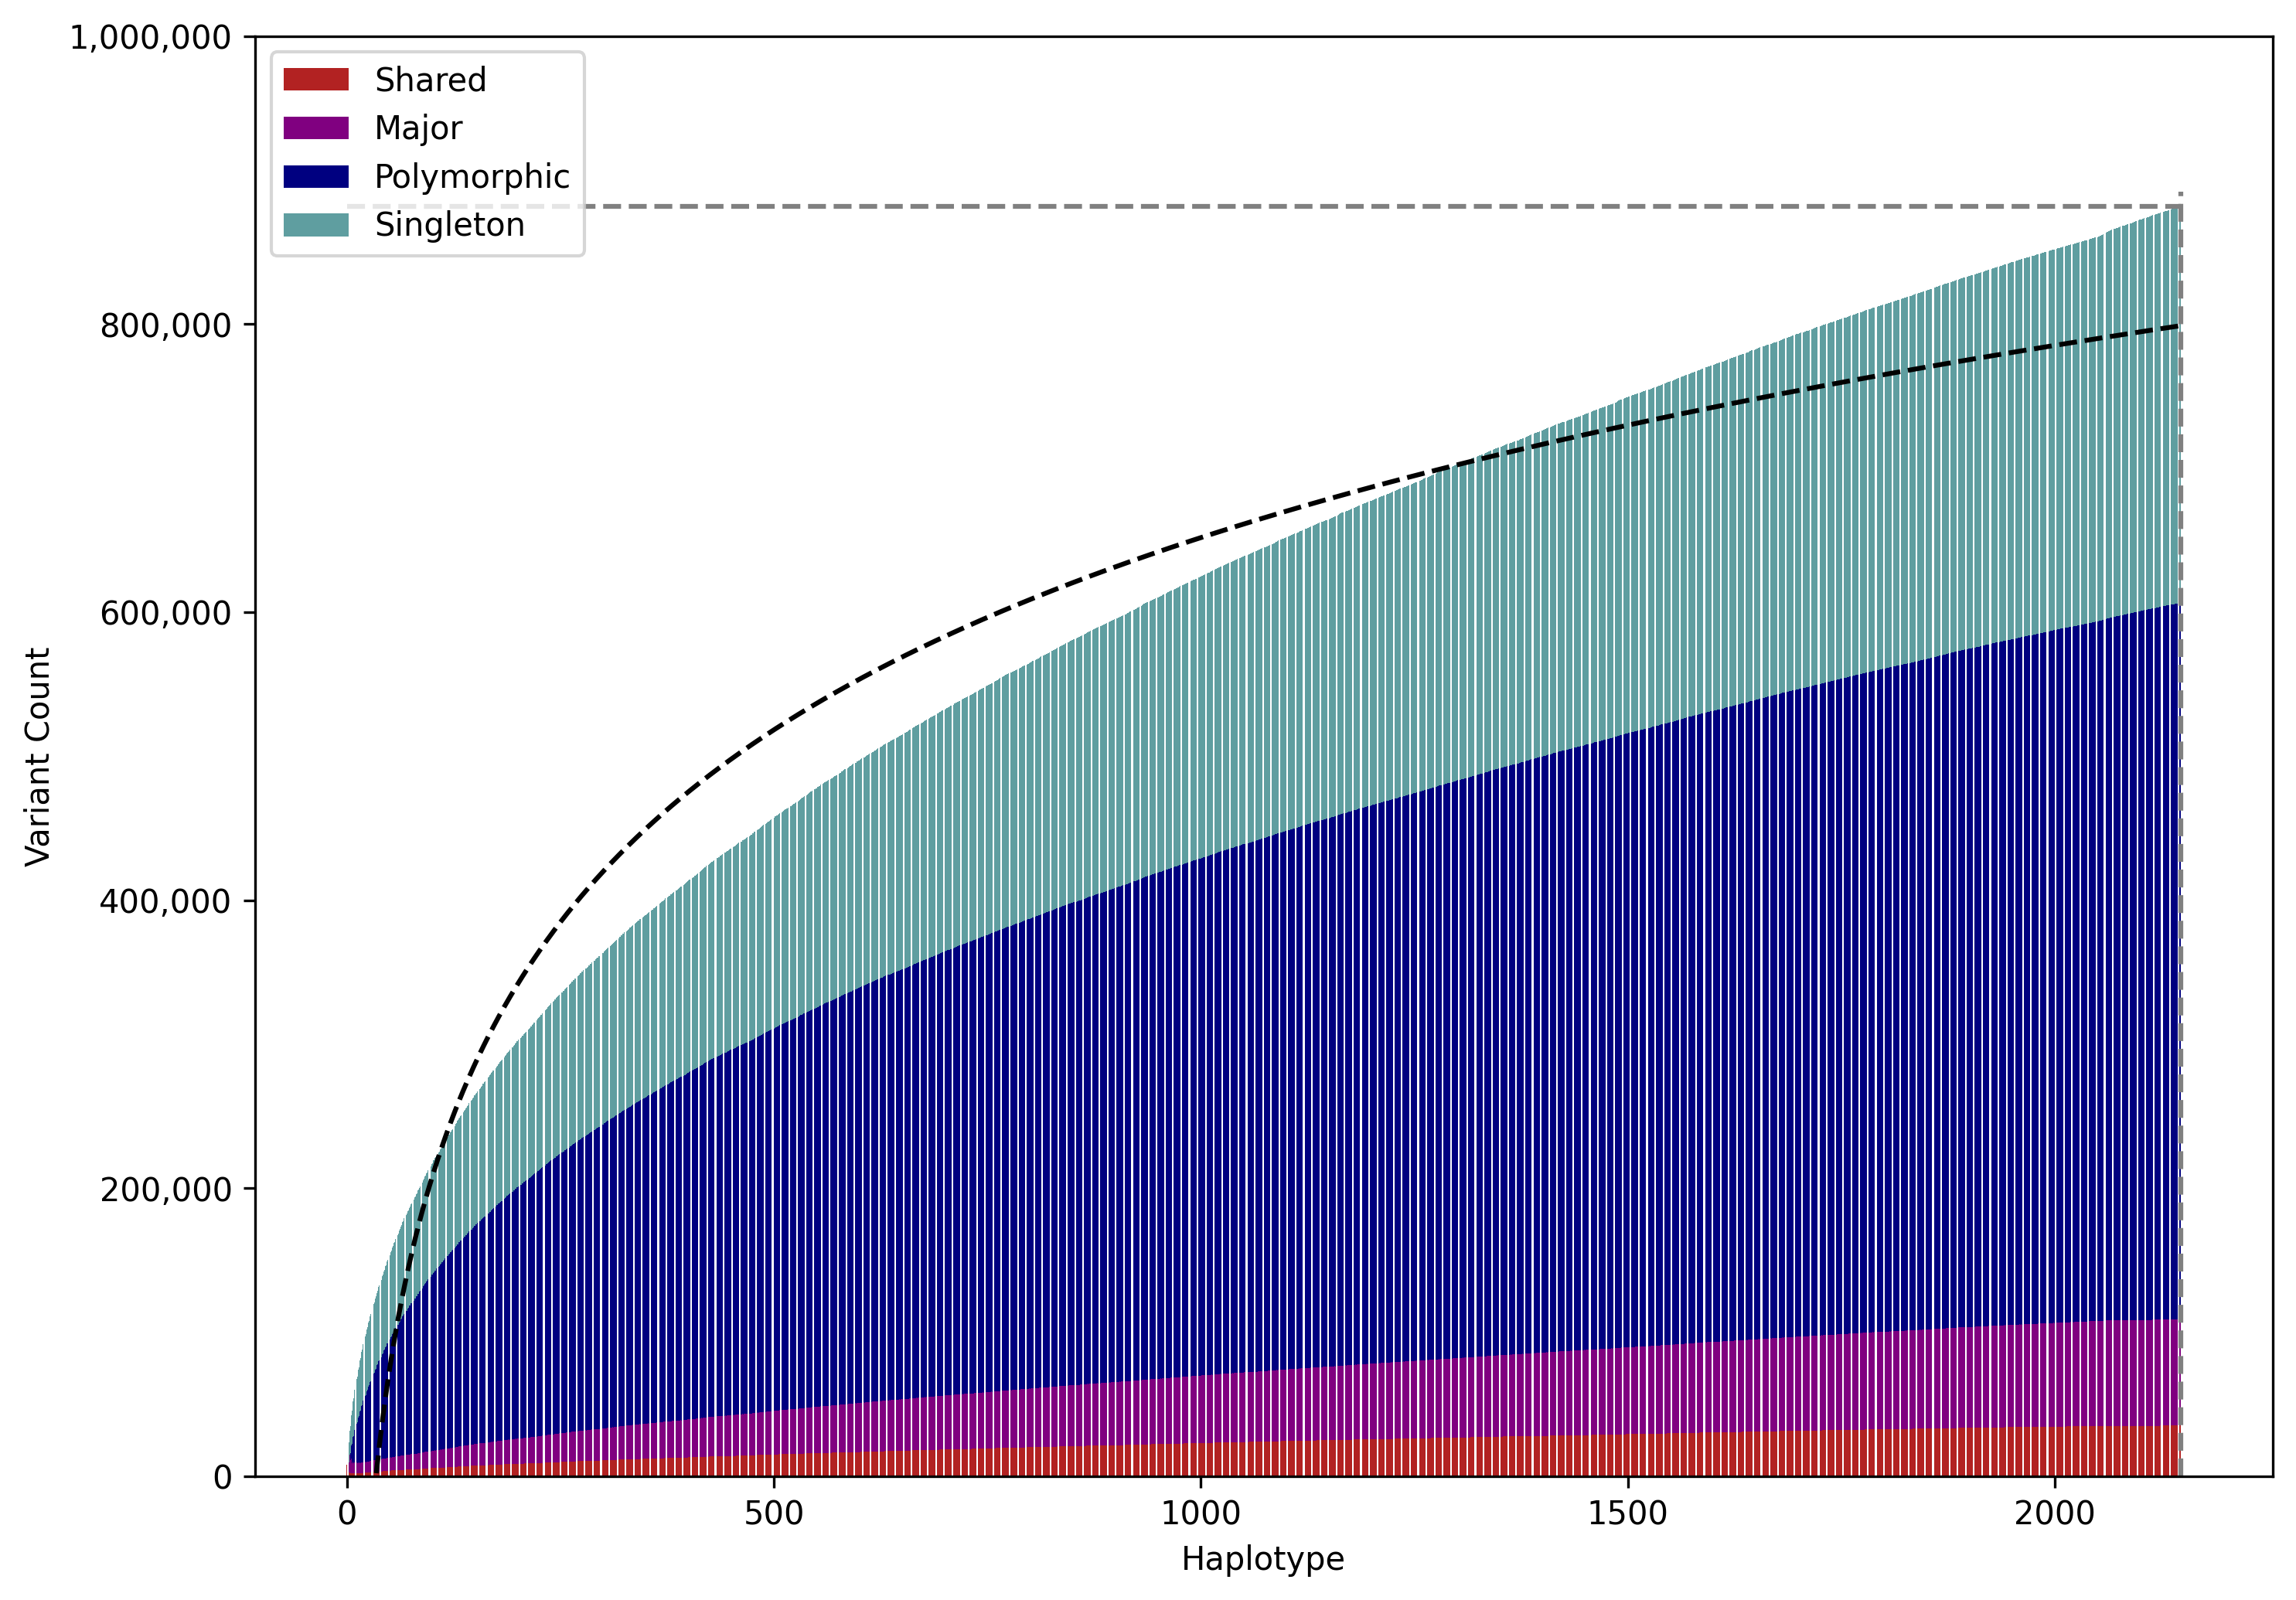

In [148]:
create_plot(my_samples, out_counts, 'test.png', 1000000)